In [228]:
%load_ext autoreload
%autoreload 2
# Select conda environment base-env with necessary libraries
# mamba activate base-env

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [229]:
# Import generic libraries
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

import matplotlib as mpl
import statsmodels.formula.api as smf

from statsmodels.stats.proportion import proportions_chisquare

mpl.rcParams['figure.dpi'] = 200


In [230]:
# Import file paths from config.py
from config import CSV_PATHS, GEOJSON_PATHS
from utils import thousands_formatter

# Section 1. Data Manipulation

## Question 1: Load the data and display a few rows of each dataset

In [231]:
# Load data
crime = pd.read_csv(CSV_PATHS['crime'])
stops = pd.read_csv(CSV_PATHS['stops'])

# Consistent lower case column namesfor easier access
crime.columns = crime.columns.str.lower()
stops.columns = stops.columns.str.lower()

In [232]:
# Display crime rows
crime.head()

,x,y,ccn,report_dat,shift,method,offense,block,xblock,yblock,...,block_group,census_tract,voting_precinct,latitude,longitude,bid,start_date,end_date,objectid,octo_record_id
0,-77.058663,38.906846,7093973,2017-06-03T12:54:27.000Z,DAY,OTHERS,THEFT FROM AUTO,2900 - 2999 BLOCK OF N STREET NW,394912,137666,...,000100 4,100.0,Precinct 5,38.906838,-77.058661,NaN,2017-06-03T11:54:03.000Z,2017-06-03T11:55:05.000Z,341397622,07093973-01
1,-77.018036,38.960747,9251904,2017-04-07T00:00:00.000Z,MIDNIGHT,OTHERS,HOMICIDE,5800 - 5899 BLOCK OF 4TH STREET NW,398437,143648,...,001902 1,1902.0,Precinct 58,38.960739,-77.018034,NaN,2009-02-13T12:03:45.000Z,2009-02-13T12:03:43.000Z,341453326,09251904-01
2,-76.984955,38.915147,14060710,2017-03-13T00:00:00.000Z,MIDNIGHT,OTHERS,HOMICIDE,2000 - 2099 BLOCK OF FENWICK STREET NE,401305,138586,...,008803 1,8803.0,Precinct 76,38.915139,-76.984953,NaN,2014-05-01T19:32:00.000Z,2014-05-01T19:32:00.000Z,341600002,14060710-01
3,-77.009722,38.824388,16217337,2017-04-03T00:00:00.000Z,MIDNIGHT,OTHERS,HOMICIDE,2 - 153 BLOCK OF GALVESTON PLACE SW,399156,128511,...,009807 2,9807.0,Precinct 126,38.824380,-77.009719,NaN,2016-12-25T11:59:35.000Z,2016-12-25T20:36:17.000Z,341698884,16217337-01
4,-77.017203,38.904526,17037020,2017-03-05T20:46:01.000Z,EVENING,OTHERS,THEFT FROM AUTO,400 - 471 BLOCK OF NEW YORK AVENUE NW,398508,137407,...,004701 2,4701.0,Precinct 1,38.904518,-77.017201,MOUNT VERNON TRIANGLE CID,2017-03-05T20:14:30.000Z,NaN,341703531,17037020-01


In [233]:
# Display stops rows
stops.head()

,stop_id,officer_id,stop_date,driver_age,driver_sex,ticket
0,52595,E,3/1/2017,37,f,True
1,46141,D,3/1/2017,16,m,True
2,154271,D,3/1/2017,16,m,True
3,184170,D,3/1/2017,23,m,True
4,91155,D,3/1/2017,18,f,True


## Question 2: Crime incidents are reported to hour/minute; stops reported to the day

In [234]:
# Extract date from report date as datetime object and create new column report_daily
crime['report_daily'] = pd.to_datetime(crime['report_dat']).dt.date
print(crime['report_daily'].head())

# Also convert stop_date to datetime object
stops['report_daily'] = pd.to_datetime(stops['stop_date']).dt.date
print(stops['report_daily'].head())

0    2017-06-03
1    2017-04-07
2    2017-03-13
3    2017-04-03
4    2017-03-05
Name: report_daily, dtype: object
0    2017-03-01
1    2017-03-01
2    2017-03-01
3    2017-03-01
4    2017-03-01
Name: report_daily, dtype: object


## Question 3: Create groupby datasets: *crimes_by_day* and *stops_by_day*

In [235]:
# Count number of crimes by day
# NOTE: sort=True is groupby default, but we can be explicit to ensure the dates are in order
crimes_by_day = (crime.groupby(crime['report_daily'], 
                              as_index=False)['objectid']
                             .nunique()
                             .rename(columns={'objectid': 'count'}))

# Confirm number of unique days in report_daily matches number of rows in crimes_by_day
print(crime['report_daily'].nunique())
print(len(crimes_by_day))

# Show crimes by day
crimes_by_day.head()

182
182


,report_daily,count
0,2017-03-01,80
1,2017-03-02,59
2,2017-03-03,84
3,2017-03-04,77
4,2017-03-05,61


In [236]:
# Count number of stops by day
# NOTE: sort=True is groupby default, but we can be explicit to ensure the dates are in order
stops_by_day = (stops.groupby(stops['report_daily'], as_index=False)['stop_id']
                             .nunique()
                             .rename(columns={'stop_id': 'count'}))

# Confirm number of unique days in stop_date matches number of rows in stops_by_day
print(stops['report_daily'].nunique())
print(len(stops_by_day))

# Show stops by day
stops_by_day.head()

174
174


,report_daily,count
0,2017-03-01,509
1,2017-03-02,421
2,2017-03-03,413
3,2017-03-04,475
4,2017-03-05,490


## Question 4: Fill missing dates
Fill missing dates with actual observed values of 0 for purposes of computing statistics. If filled with Nan, statistics would be biased upward.

In [237]:
# Create simple function to fill missing dates in a DataFrame with 0 counts
def fill_missing_dates(
    df: pd.DataFrame, 
    date_col: str = "report_daily", 
    fill_col: str = "count", 
    fill_value: int = 0) -> pd.DataFrame:
    """
    Fill missing dates in a DataFrame with 0 counts.
    """
    # Create complete date range from min to max date
    date_range = pd.date_range(start=df[date_col].min(), end=df[date_col].max(), freq='D')

    # Convert date column to datetime type (if not already)
    df[date_col] = pd.to_datetime(df[date_col])
        
    # Extract dates missing from crimes_by_day 
    idx = ~date_range.isin(df[date_col])
    print(f"{sum(idx)}/{len(date_range)} missing dates.")

    # Append and sort missing dates with fill value
    if sum(idx) > 0:
        
        # Create df with missing dates and fill value
        missing_df = pd.DataFrame({date_col: date_range[idx], fill_col: fill_value})

        # Concatenate missing dates
        df = pd.concat([df, missing_df]).sort_values(by=date_col).reset_index(drop=True)
    
    return df


In [238]:
# Add missing dates to crimes_by_day
crimes_by_day = fill_missing_dates(crimes_by_day)

# Add missing dates to stops_by_day
stops_by_day = fill_missing_dates(stops_by_day)

# Show missing dates with 0 traffic stops
stops_by_day[stops_by_day["count"]==0]

0/182 missing dates.
8/182 missing dates.


,report_daily,count
29,2017-03-30,0
30,2017-03-31,0
60,2017-04-30,0
90,2017-05-30,0
91,2017-05-31,0
121,2017-06-30,0
151,2017-07-30,0
152,2017-07-31,0


## Question 5: Merge traffic stops and crime data

In [239]:
# Merge dfs
df = stops_by_day.merge(crimes_by_day, on="report_daily", how='left', suffixes=('_stops', '_crimes'))
df

,report_daily,count_stops,count_crimes
0,2017-03-01,509,80
1,2017-03-02,421,59
2,2017-03-03,413,84
3,2017-03-04,475,77
4,2017-03-05,490,61
...,...,...,...
177,2017-08-25,475,94
178,2017-08-26,471,114
179,2017-08-27,444,106
180,2017-08-28,476,74


In [240]:
# Date with max traffic stops
max_stops_date, max_stops, _ = df.loc[df['count_stops'].idxmax()]
print(f"Max traffic stops: 1) date: {max_stops_date.strftime('%Y-%m-%d')}, 2) count: {max_stops}, 3) day of week: {max_stops_date.date().strftime('%A')}")

Max traffic stops: 1) date: 2017-05-01, 2) count: 535, 3) day of week: Monday


In [241]:
# Date with max crimes
max_crimes_date, max_crimes, _ = df.loc[df['count_crimes'].idxmax()]
print(f"Max crimes: 1) date: {max_crimes_date.strftime('%Y-%m-%d')}, 2) count: {max_crimes}, 3) day of week: {max_crimes_date.date().strftime('%A')}")

Max crimes: 1) date: 2017-05-08, 2) count: 410, 3) day of week: Monday


## Question 6: most common July 4 crime

In [242]:
# Ensure report_daily is datetime type to use dt accessor
crime['report_daily'] = pd.to_datetime(crime['report_daily'])

# Extract July 4th
idx = (crime['report_daily'].dt.month == 7) & (crime['report_daily'].dt.day == 4)

# Count crimes by offense on July 4th
offense_counts = crime[idx].groupby("offense").size().sort_values(ascending=False)

# Extract most frequent offense on July 4th
print(f"Most frequent July 4 crime: {offense_counts.index[0]}, count: {offense_counts.iloc[0]}")
print(offense_counts)


Most frequent July 4 crime: THEFT FROM AUTO, count: 22
offense
THEFT FROM AUTO               22
THEFT/OTHER                   20
MOTOR VEHICLE THEFT           13
THEFT_OTHER                   11
ROBBERY                        7
ASSAULT W/DANGEROUS WEAPON     6
BURGLARY                       2
THEFT OTHER                    2
dtype: int64


# Section 2: Policy Evaluation

In [243]:
# NOTE: Courts data has 3 column names, but comma separator produces 4 columns for some rows
# Based on note that traffic tickets are in $0.50 increments, 
# I assume the extra column in some cases is using comma as a decimal separator
# NOTE: I added a dummy column name "ticket_cents" to facilitate the cleaning

# Load data
courts = pd.read_csv(CSV_PATHS['courts'])
courts.head(10)

,stop_id,ticket_amount,ticket_status,dummy
0,175978,40,overdue,NaN
1,63356,40,paid,NaN
2,92046,45,paid,NaN
3,173651,45,overdue,NaN
4,52624,65,paid,NaN
5,147991,47,overdue,NaN
6,9957,55,overdue,NaN
7,186564,40,50,paid
8,106970,45,challenged,NaN
9,65657,30,overdue,NaN


In [244]:
# Extract ticket cents from ticket_status and fill missing values in ticket_status with ticket_cents
ticket_cents = pd.to_numeric(courts['ticket_status'], errors='coerce').fillna(0)/100
courts['ticket_amount'] += ticket_cents
courts.head(10)

,stop_id,ticket_amount,ticket_status,dummy
0,175978,40.0,overdue,NaN
1,63356,40.0,paid,NaN
2,92046,45.0,paid,NaN
3,173651,45.0,overdue,NaN
4,52624,65.0,paid,NaN
5,147991,47.0,overdue,NaN
6,9957,55.0,overdue,NaN
7,186564,40.5,50,paid
8,106970,45.0,challenged,NaN
9,65657,30.0,overdue,NaN


In [245]:
# Fill missing values in ticket_status that were right shifted due to ticket_cents
idx = ~courts['dummy'].isna()
courts.loc[idx, 'ticket_status'] = courts[idx]['dummy']

# Drop dummy column
courts.drop(columns=['dummy'], inplace=True)
courts.head(10)


,stop_id,ticket_amount,ticket_status
0,175978,40.0,overdue
1,63356,40.0,paid
2,92046,45.0,paid
3,173651,45.0,overdue
4,52624,65.0,paid
5,147991,47.0,overdue
6,9957,55.0,overdue
7,186564,40.5,paid
8,106970,45.0,challenged
9,65657,30.0,overdue


In [246]:
# Read income data
income = pd.read_csv(CSV_PATHS['income'])
income.head(10)

,stop_id,income
0,97294,26305
1,87077,77578
2,57432,80185
3,121675,98784
4,37238,9350
5,199246,31981
6,191139,42301
7,153865,52278
8,90007,21719
9,111167,34801


In [247]:
# Merge courts and income data on stop_id
df = courts.merge(income, on="stop_id", how='left')

# Check lengths of courts, income, and merged df to confirm merge worked as expected
print(len(courts), len(income), len(df))
df.head()

60257 60268 60257


,stop_id,ticket_amount,ticket_status,income
0,175978,40.0,overdue,NaN
1,63356,40.0,paid,104461.0
2,92046,45.0,paid,67931.0
3,173651,45.0,overdue,35424.0
4,52624,65.0,paid,88920.0


In [248]:
# Exclude pending & challenging for paid/unpaid analysis
df = df[df.ticket_status.isin(["paid","overdue"])]

# Convert to binary for logit regression
df['paid'] = (df.ticket_status == 'paid').astype(int)

# Drop any missing (income data)
df = df.dropna().reset_index(drop=True)

## Question 7: Delta probability less/greater than $30,000

In [249]:
# Define parameters
INCOME_THRESHOLD = 30000
INCOME_THRESHOLDS = np.arange(5000, 55000, 5000)
BANDWIDTH = 5000

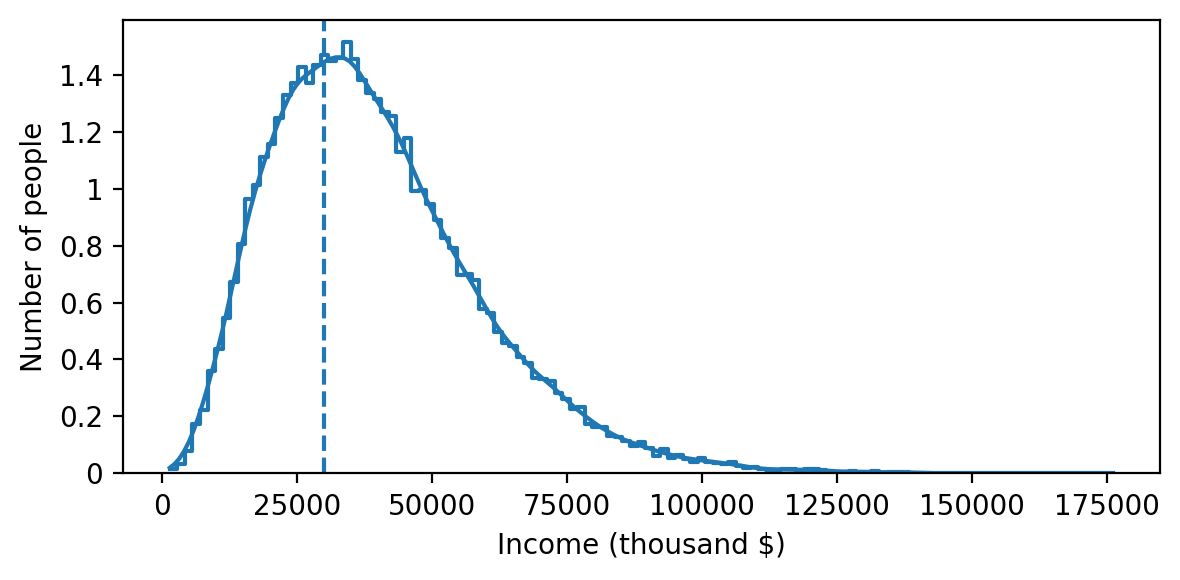

In [250]:
# Examine continuity of income distribution around policy threshold
# Confirm smooth/continous at policy threshold: $30,000
fig, ax = plt.subplots(figsize=(6,3), tight_layout=True)
sns.histplot(df["income"], kde=True, element="step", fill=False, ax=ax)
ax.axvline(INCOME_THRESHOLD, ls="--")
ax.set(xlabel="Income (thousand $)", ylabel="Number of people")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(thousands_formatter))



In [251]:
# Consider only within window of threshold
df2 = df[df.income.between(INCOME_THRESHOLD - BANDWIDTH, 
                           INCOME_THRESHOLD + BANDWIDTH)].reset_index(drop=True)

# Determine people below/above income threshold
below_idx = (df2['income'] < INCOME_THRESHOLD)
above_idx = (df2['income'] >= INCOME_THRESHOLD)

# Extract people with paid tickets below/above income threshold
paid_below_idx = (df2['ticket_status'] == 'paid') & below_idx
paid_above_idx = (df2['ticket_status'] == 'paid') & above_idx

# Get counts
nbelow, nabove = sum(below_idx), sum(above_idx)
npaid_below, npaid_above = sum(paid_below_idx), sum(paid_above_idx)


In [252]:
# Create summary table
tab = pd.DataFrame({"group": ["below","above"],
                    "npaid": [npaid_below, npaid_above], 
                    "npeople": [nbelow, nabove]})
# Add proportion paid
tab["ppaid"] = tab["npaid"]/tab["npeople"]
tab

,group,npaid,npeople,ppaid
0,below,2110,5038,0.418817
1,above,1253,5300,0.236415


### Compute policy impacts: observed differences at threshold

In [253]:
# Compute policy impact: treated: marginally below income threshold receiving reduced ticked MINUS marginally above threshold no fine reduction 
ppaid_below, ppaid_above = tab["ppaid"]
policy_impact = ppaid_below - ppaid_above

In [254]:
# Perform Chi-square test
stat, pval, table = proportions_chisquare(tab.npaid, tab.npeople)
print(f"Statistic: {stat:.4f}, P-value: {pval:.4f}")

Statistic: 391.5238, P-value: 0.0000


### Compute policy impacts: logit regression

In [255]:
# Create binary variable for treatment
df2["group"] = pd.cut(
    df2.income,
    bins=[0, INCOME_THRESHOLD, float("inf")],
    labels=[1, 0] # 1 = treated (below income threshold)
)
df2.head()

,stop_id,ticket_amount,ticket_status,income,paid,group
0,65657,30.0,overdue,31443.0,0,0
1,126317,30.5,overdue,34774.0,0,0
2,192475,55.0,overdue,30612.0,0,0
3,21109,34.5,overdue,25396.0,0,1
4,1326,70.5,paid,28887.0,1,1


In [256]:
# Specify logit model
model = smf.logit("paid ~ group + income", data=df2).fit()

# Extract coefficient & p-value on above/below threshold
beta = model.params['group[T.0]'].item()
pval = model.pvalues['group[T.0]'].item()

# Model summary
model.summary()


Optimization terminated successfully.
         Current function value: 0.611748
         Iterations 5


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                   paid   No. Observations:                10338
Model:                          Logit   Df Residuals:                    10335
Method:                           MLE   Df Model:                            2
Date:                Sun, 19 Apr 2026   Pseudo R-squ.:                 0.03021
Time:                        21:15:52   Log-Likelihood:                -6324.3
converged:                       True   LL-Null:                       -6521.2
Covariance Type:            nonrobust   LLR p-value:                 2.793e-86
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.4264      0.405     -1.052      0.293      -1.220       0.368
group[T.0]    -0.8621      0.085    -10.112      0.000      -1.029      -0.695
income      3.578e-06   1.47e-05      0.243      0.808   -2.52e-05    3.24e-05
==============================================================================
"""

In [257]:
# Predict logit above and below threshold
predicted = pd.DataFrame({'group': [0, 1], 'income': [INCOME_THRESHOLD, INCOME_THRESHOLD]})
logit_above, logit_below = model.predict(predicted, linear=True)

# Convert logit to probability
prob_above = np.exp(logit_above) / (1 + np.exp(logit_above))
prob_below = np.exp(logit_below) / (1 + np.exp(logit_below))
logit_delta_prob = prob_below - prob_above

/Users/carlossilva/miniforge3/envs/base-env/lib/python3.14/site-packages/statsmodels/discrete/discrete_model.py:530: FutureWarning: linear keyword is deprecated, use which="linear"
  warnings.warn(msg, FutureWarning)


## Question 8: Magnitude of impact
Reduced fine for low income people nearly doubled probability of paying from 24% (income: $30-$35k) to 42% (income $25-$30k). Policy considerations: 
1. **Revenue**: Increased payment probability (~2x) more than compensates for 20-40% foregone revenue of low income fines due to policy.

2. **Credit scores**: Increased payment may marginally improve credit scores of low income individuals with unpaid tickets.

3. **Deterrent**: Unknown whether lower ticket amount reduces deterrence for traffic violations, most importantly, speeding fines given importance of DC Vision Zero to eliminate traffic fatalities within the distict.


In [258]:
# Simple difference at threshold results
print(f"Probability of paid ticket with policy (reduced ticket): {ppaid_below:.1%}")
print(f"Probability of paid ticket without policy (no reduction): {ppaid_above:.1%}")
print(f"Policy impact (below - above income threshold): {policy_impact:.1%}")

Probability of paid ticket with policy (reduced ticket): 41.9%
Probability of paid ticket without policy (no reduction): 23.6%
Policy impact (below - above income threshold): 18.2%


In [259]:
# Logit regression discontinuity results
print(f"Probability of paid ticket with policy (reduced ticket): {prob_below:.1%}")
print(f"Probability of paid ticket without policy (no reduction): {prob_above:.1%}")
print(f"Policy impact (below - above income threshold): {logit_delta_prob:.1%}")

Probability of paid ticket with policy (reduced ticket): 42.1%
Probability of paid ticket without policy (no reduction): 23.5%
Policy impact (below - above income threshold): 18.6%


## Question 9: Results across income thresholds

In [260]:
def chisquared_test(df: pd.DataFrame, 
                    income_thresholds: np.ndarray | list = INCOME_THRESHOLDS,
                    bandwidth: float = BANDWIDTH) -> tuple:
    """
    Function to compute p-value for Chi-squared test on difference in proportions
    """
    # Initalize output
    pvals, tabs = [], []
    # Loop over income thresholds
    for income_threshold in income_thresholds:

        if bandwidth == 0:
            tmp = df.copy()    
        else:
            tmp = df[df.income.between(income_threshold - bandwidth, 
                               income_threshold + bandwidth)].reset_index(drop=True)

        # Determine people below/above income threshold
        below_idx = (tmp['income'] < income_threshold)
        above_idx = (tmp['income'] >= income_threshold)

        # Extract people with paid tickets below/above income threshold
        paid_below_idx = (tmp['ticket_status'] == 'paid') & below_idx
        paid_above_idx = (tmp['ticket_status'] == 'paid') & above_idx

        # Get counts
        nbelow, nabove = sum(below_idx), sum(above_idx)
        npaid_below, npaid_above = sum(paid_below_idx), sum(paid_above_idx)

        # Create summary table
        tab = pd.DataFrame({"threshold": income_threshold,
                            "group": ["below","above"],
                            "npaid": [npaid_below, npaid_above], 
                            "npeople": [nbelow, nabove]})
        
        # Add proportion paid
        tab["ppaid"] = tab["npaid"]/tab["npeople"]

        # Compute chi-square test
        _, pval, __ = proportions_chisquare(tab.npaid, tab.npeople)
        pvals.append(pval.item())
        tabs.append(tab)
    return pvals, tabs

In [261]:
# NOTE: Bandwidth assumes test p
chisquared_pvals, tabs = chisquared_test(df, bandwidth=BANDWIDTH)

# Concatenate summary tables and pivot for plotting
results = pd.concat(tabs).pivot(index='threshold', 
                                columns='group', 
                                values='ppaid').reset_index()
results

group,threshold,above,below
0,5000,0.404790,0.373626
1,10000,0.423745,0.404790
2,15000,0.412503,0.423944
3,20000,0.413365,0.412729
4,25000,0.418734,0.413238
5,30000,0.236415,0.418817
6,35000,0.263940,0.236415
7,40000,0.304792,0.263940
8,45000,0.332704,0.304703
9,50000,0.367667,0.332704


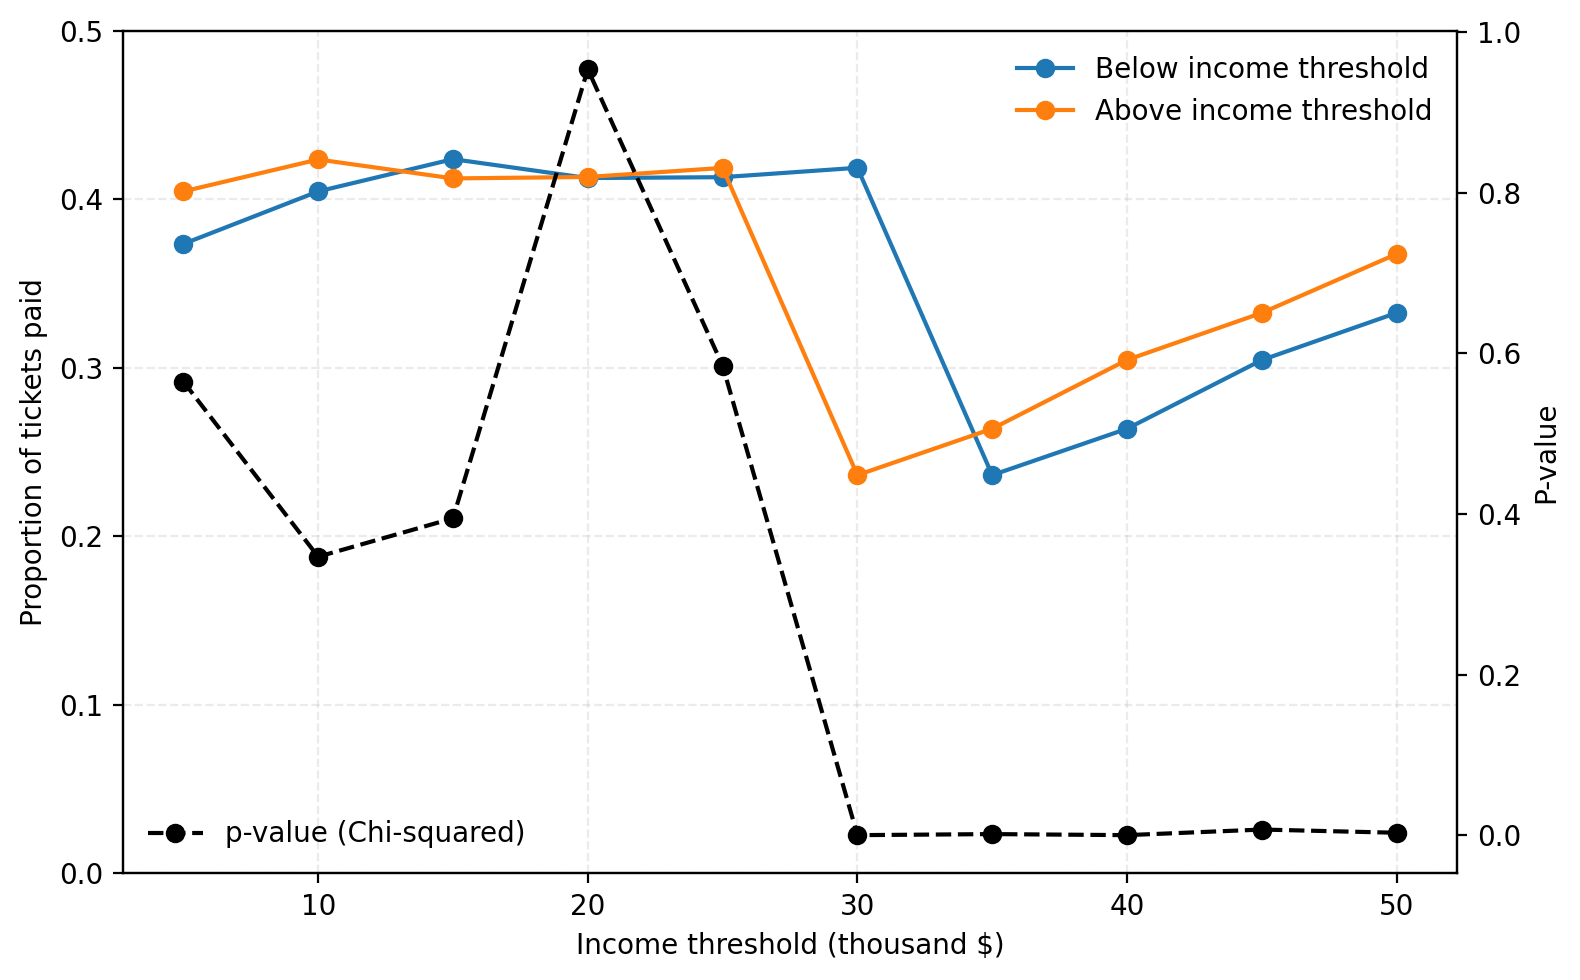

In [262]:
# Plot estimated impact and p-values
fig, ax0 = plt.subplots(figsize=(8,5), tight_layout=True)

# Plot estimated impact
ax0.plot(results.threshold, results.below, marker="o", ls="-", label="Below income threshold")
ax0.plot(results.threshold, results.above, marker="o", ls="-", label="Above income threshold")
ax0.set(xlabel="Income threshold (thousand $)", ylabel="Proportion of tickets paid", 
        ylim=(0,0.5)
        )
ax0.xaxis.set_major_formatter(mtick.FuncFormatter(thousands_formatter))

ax0.grid(zorder=0, ls="--", alpha=0.25)
ax0.legend(frameon=False)

# Plot p-values
ax1 = ax0.twinx()
ax1.plot(results.threshold, chisquared_pvals, marker="o", ls="--", color="k", label="p-value (Chi-squared)")
ax1.set(ylabel="P-value")
ax1.legend(frameon=False, loc="lower left")



In [263]:
# Run Chi-squared test across income thresholds with bandwidth of 0
# NOTE: simple difference in proportions of all individual above and below income thresholds 
# as opposed to within bandwith around supposed cutoff for reduced ticked policy
chisquared_pvals, tabs = chisquared_test(df, bandwidth=0)

# Concatenate summary tables and pivot for plotting
results = pd.concat(tabs).pivot(index='threshold', 
                                columns='group', 
                                values='ppaid').reset_index()
results

group,threshold,above,below
0,5000,0.371337,0.373626
1,10000,0.370729,0.401728
2,15000,0.368138,0.417212
3,20000,0.364067,0.414768
4,25000,0.357706,0.414147
5,30000,0.347601,0.415586
6,35000,0.371016,0.371720
7,40000,0.396998,0.351781
8,45000,0.422623,0.345089
9,50000,0.450062,0.343765


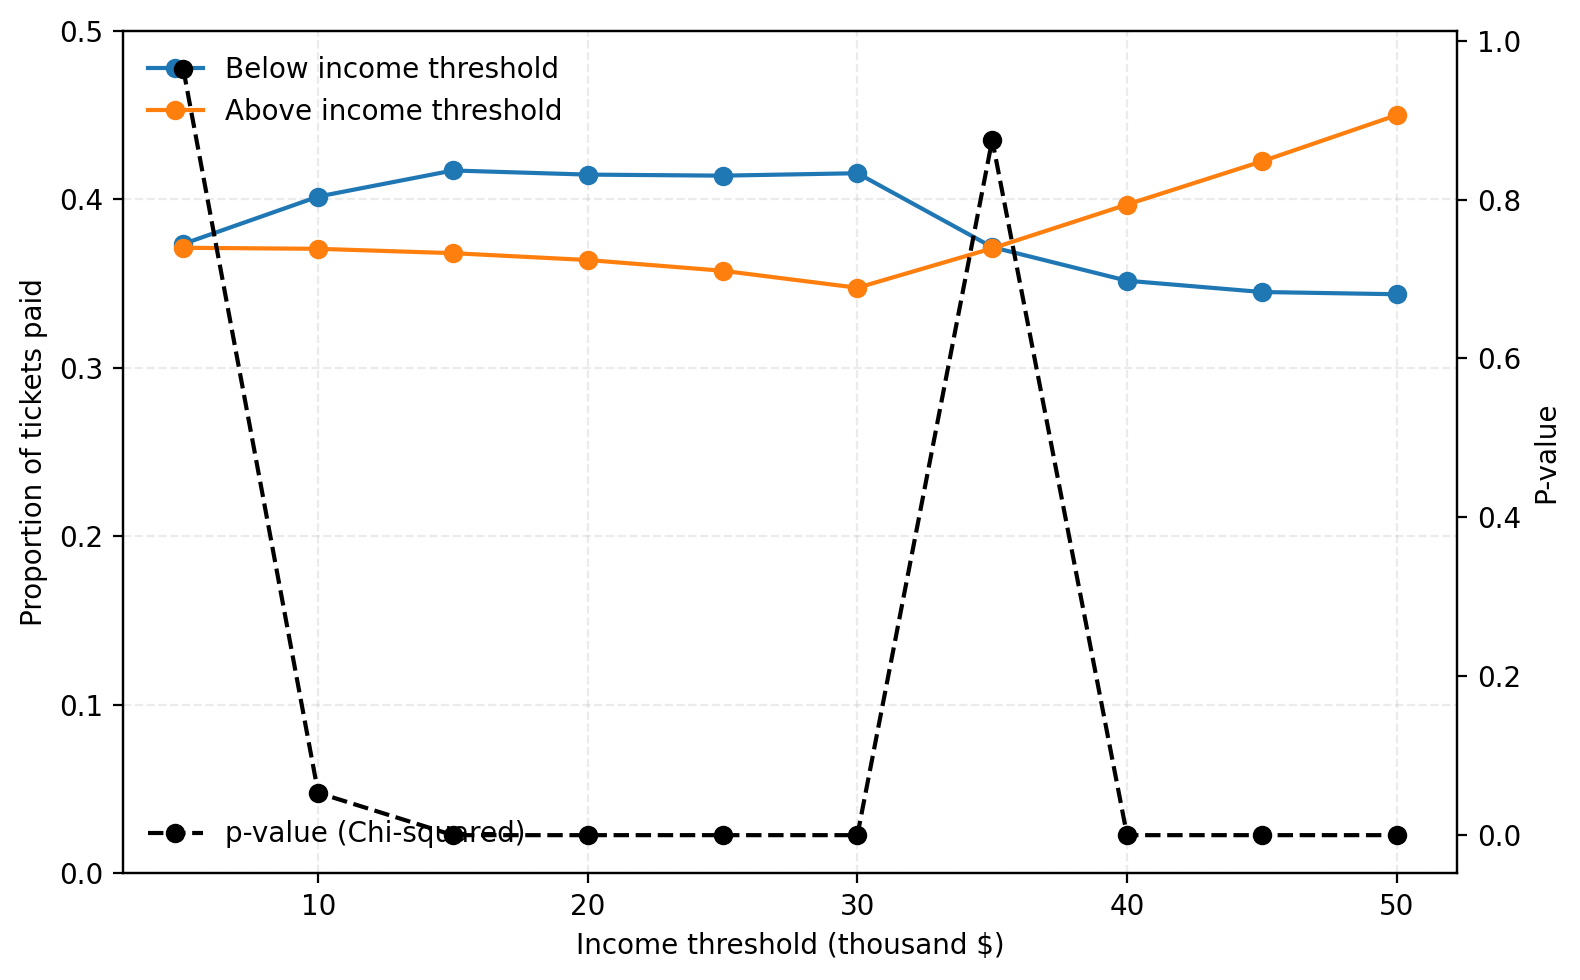

In [264]:
# Plot estimated impact and p-values
fig, ax0 = plt.subplots(figsize=(8,5), tight_layout=True)

# Plot estimated impact
ax0.plot(results.threshold, results.below, marker="o", ls="-", label="Below income threshold")
ax0.plot(results.threshold, results.above, marker="o", ls="-", label="Above income threshold")
ax0.set(xlabel="Income threshold (thousand $)", ylabel="Proportion of tickets paid", 
        ylim=(0,0.5)
        )
ax0.xaxis.set_major_formatter(mtick.FuncFormatter(thousands_formatter))

ax0.grid(zorder=0, ls="--", alpha=0.25)
ax0.legend(frameon=False)

# Plot p-values
ax1 = ax0.twinx()
ax1.plot(results.threshold, chisquared_pvals, marker="o", ls="--", color="k", label="p-value (Chi-squared)")
ax1.set(ylabel="P-value")
ax1.legend(frameon=False, loc="lower left")



## Question 10: Discussion of impact

*Did new reduced payment policy have a detectable impact on likelihood of an overdue ticket?*

Yes, reduced fine for low income people nearly doubled probability of paying from 24% (income: $30-$35k) to 42% (income $25-$30k).

*What problems might this analysis have in capturing causal effect of the policy?* 
1. Deliberately reporting lower income (if self-reported) to receive lower fine.

2. Additional covariates correlated with income that could account for observed difference in payment above/below $30,000 (e.g., education level).

3. If policy requires opt-in to receive fine reduction, self-selection could confound impact estimate, as those who opt-in may be more likely to pay anyway.

*How would you suggest overcoming those problems?*
1. Use tax returns as opposed to self-reporting to determine income in order to avoid manipulation.

2. Add additional covariates, such as education level, though requires more data gathering/survey effort than could be warranted.

3. Automatically apply fine reduction based on tax returns (if available) to avoid self-selection.


# Section 3: Data Visualization
## Question 11: Create data visualization

### Data prep

In [265]:
# Read address points data
address = gpd.read_file(GEOJSON_PATHS['address_points'])
print(address.columns)

Index(['OBJECTID', 'MAR_ID', 'ADDRESS', 'ADDRESS_NUMBER',
       'ADDRESS_NUMBER_SUFFIX', 'STREET_NAME', 'STREET_TYPE', 'QUADRANT',
       'ZIPCODE', 'CITY', 'STATE', 'COUNTRY', 'X_COORDINATE', 'Y_COORDINATE',
       'LATITUDE', 'LONGITUDE', 'ADDRESS_TYPE', 'STATUS', 'ROUTEID',
       'BLOCKKEY', 'SUBBLOCKKEY', 'WARD', 'METADATA_ID', 'NATIONAL_GRID',
       'HAS_SSL', 'HAS_PLACE_NAME', 'HAS_CONDO', 'HAS_RESIDENTIAL_UNIT',
       'STREET_VIEW_URL', 'RESIDENTIAL_TYPE', 'PLACEMENT', 'SSL_ALIGNMENT',
       'BUILDING', 'SSL', 'SQUARE', 'SUFFIX', 'LOT', 'MULTIPLE_LAND_SSL',
       'GRID_DIRECTION', 'HOUSING_UNIT_COUNT', 'RESIDENTIAL_UNIT_COUNT',
       'BEFORE_DATE', 'BEFORE_DATE_SOURCE', 'BEGIN_DATE', 'BEGIN_DATE_SOURCE',
       'FIRST_KNOWN_DATE', 'FIRST_KNOWN_DATE_SOURCE', 'CREATED_DATE',
       'LAST_EDITED_DATE', 'SE_ANNO_CAD_DATA', 'SMD', 'ANC', 'geometry'],
      dtype='str')


In [266]:
# Examine address types
print(address.RESIDENTIAL_TYPE.value_counts())

# ---- PRE-PROCESSING ----
# 1. NOTE: separate primary (HOUSING_UNIT_COUNT) and secondary (RESIDENTIAL_UNIT_COUNT) housing counts
print(address[["RESIDENTIAL_UNIT_COUNT","HOUSING_UNIT_COUNT"]].head())
# 2. NOTE: data include both residential and non-residential addresses
print(address.RESIDENTIAL_TYPE.value_counts())

# Sum primary (HOUSING_UNIT_COUNT) and secondary (RESIDENTIAL_UNIT_COUNT) housing units to get total housing units
address["total_housing_units"] = address["HOUSING_UNIT_COUNT"] + address["RESIDENTIAL_UNIT_COUNT"]

# Drop non-residential addresses
idx = address['RESIDENTIAL_TYPE'].isin(['RESIDENTIAL', "MIXED USE"]) & (address['total_housing_units'] > 0)
address = address[idx].reset_index(drop=True)


RESIDENTIAL_TYPE
RESIDENTIAL        130417
NON RESIDENTIAL     13307
MIXED USE             648
Name: count, dtype: int64
   RESIDENTIAL_UNIT_COUNT  HOUSING_UNIT_COUNT
0                     0.0                 1.0
1                     1.0                 2.0
2                     0.0                 1.0
3                     1.0                 2.0
4                     0.0                 1.0
RESIDENTIAL_TYPE
RESIDENTIAL        130417
NON RESIDENTIAL     13307
MIXED USE             648
Name: count, dtype: int64


In [267]:
# Extract year of construction from BEGIN_DATE
address["year"] = address["BEGIN_DATE"].dt.year

# Set erroneous years to Nat
idx = (address["year"] < 1850) | (address["year"] > 2026) 
address.loc[idx, "year"] = np.nan


In [268]:
# Assign housing types based on total_housing_units
address["housing_type"] = pd.cut(
    address.total_housing_units,
    bins=[0, 1, 10, float("inf")],
    labels=["Single family", "Multi-family", "Building"]
)

### Map view: Spatial distribution of recent construction by housing type

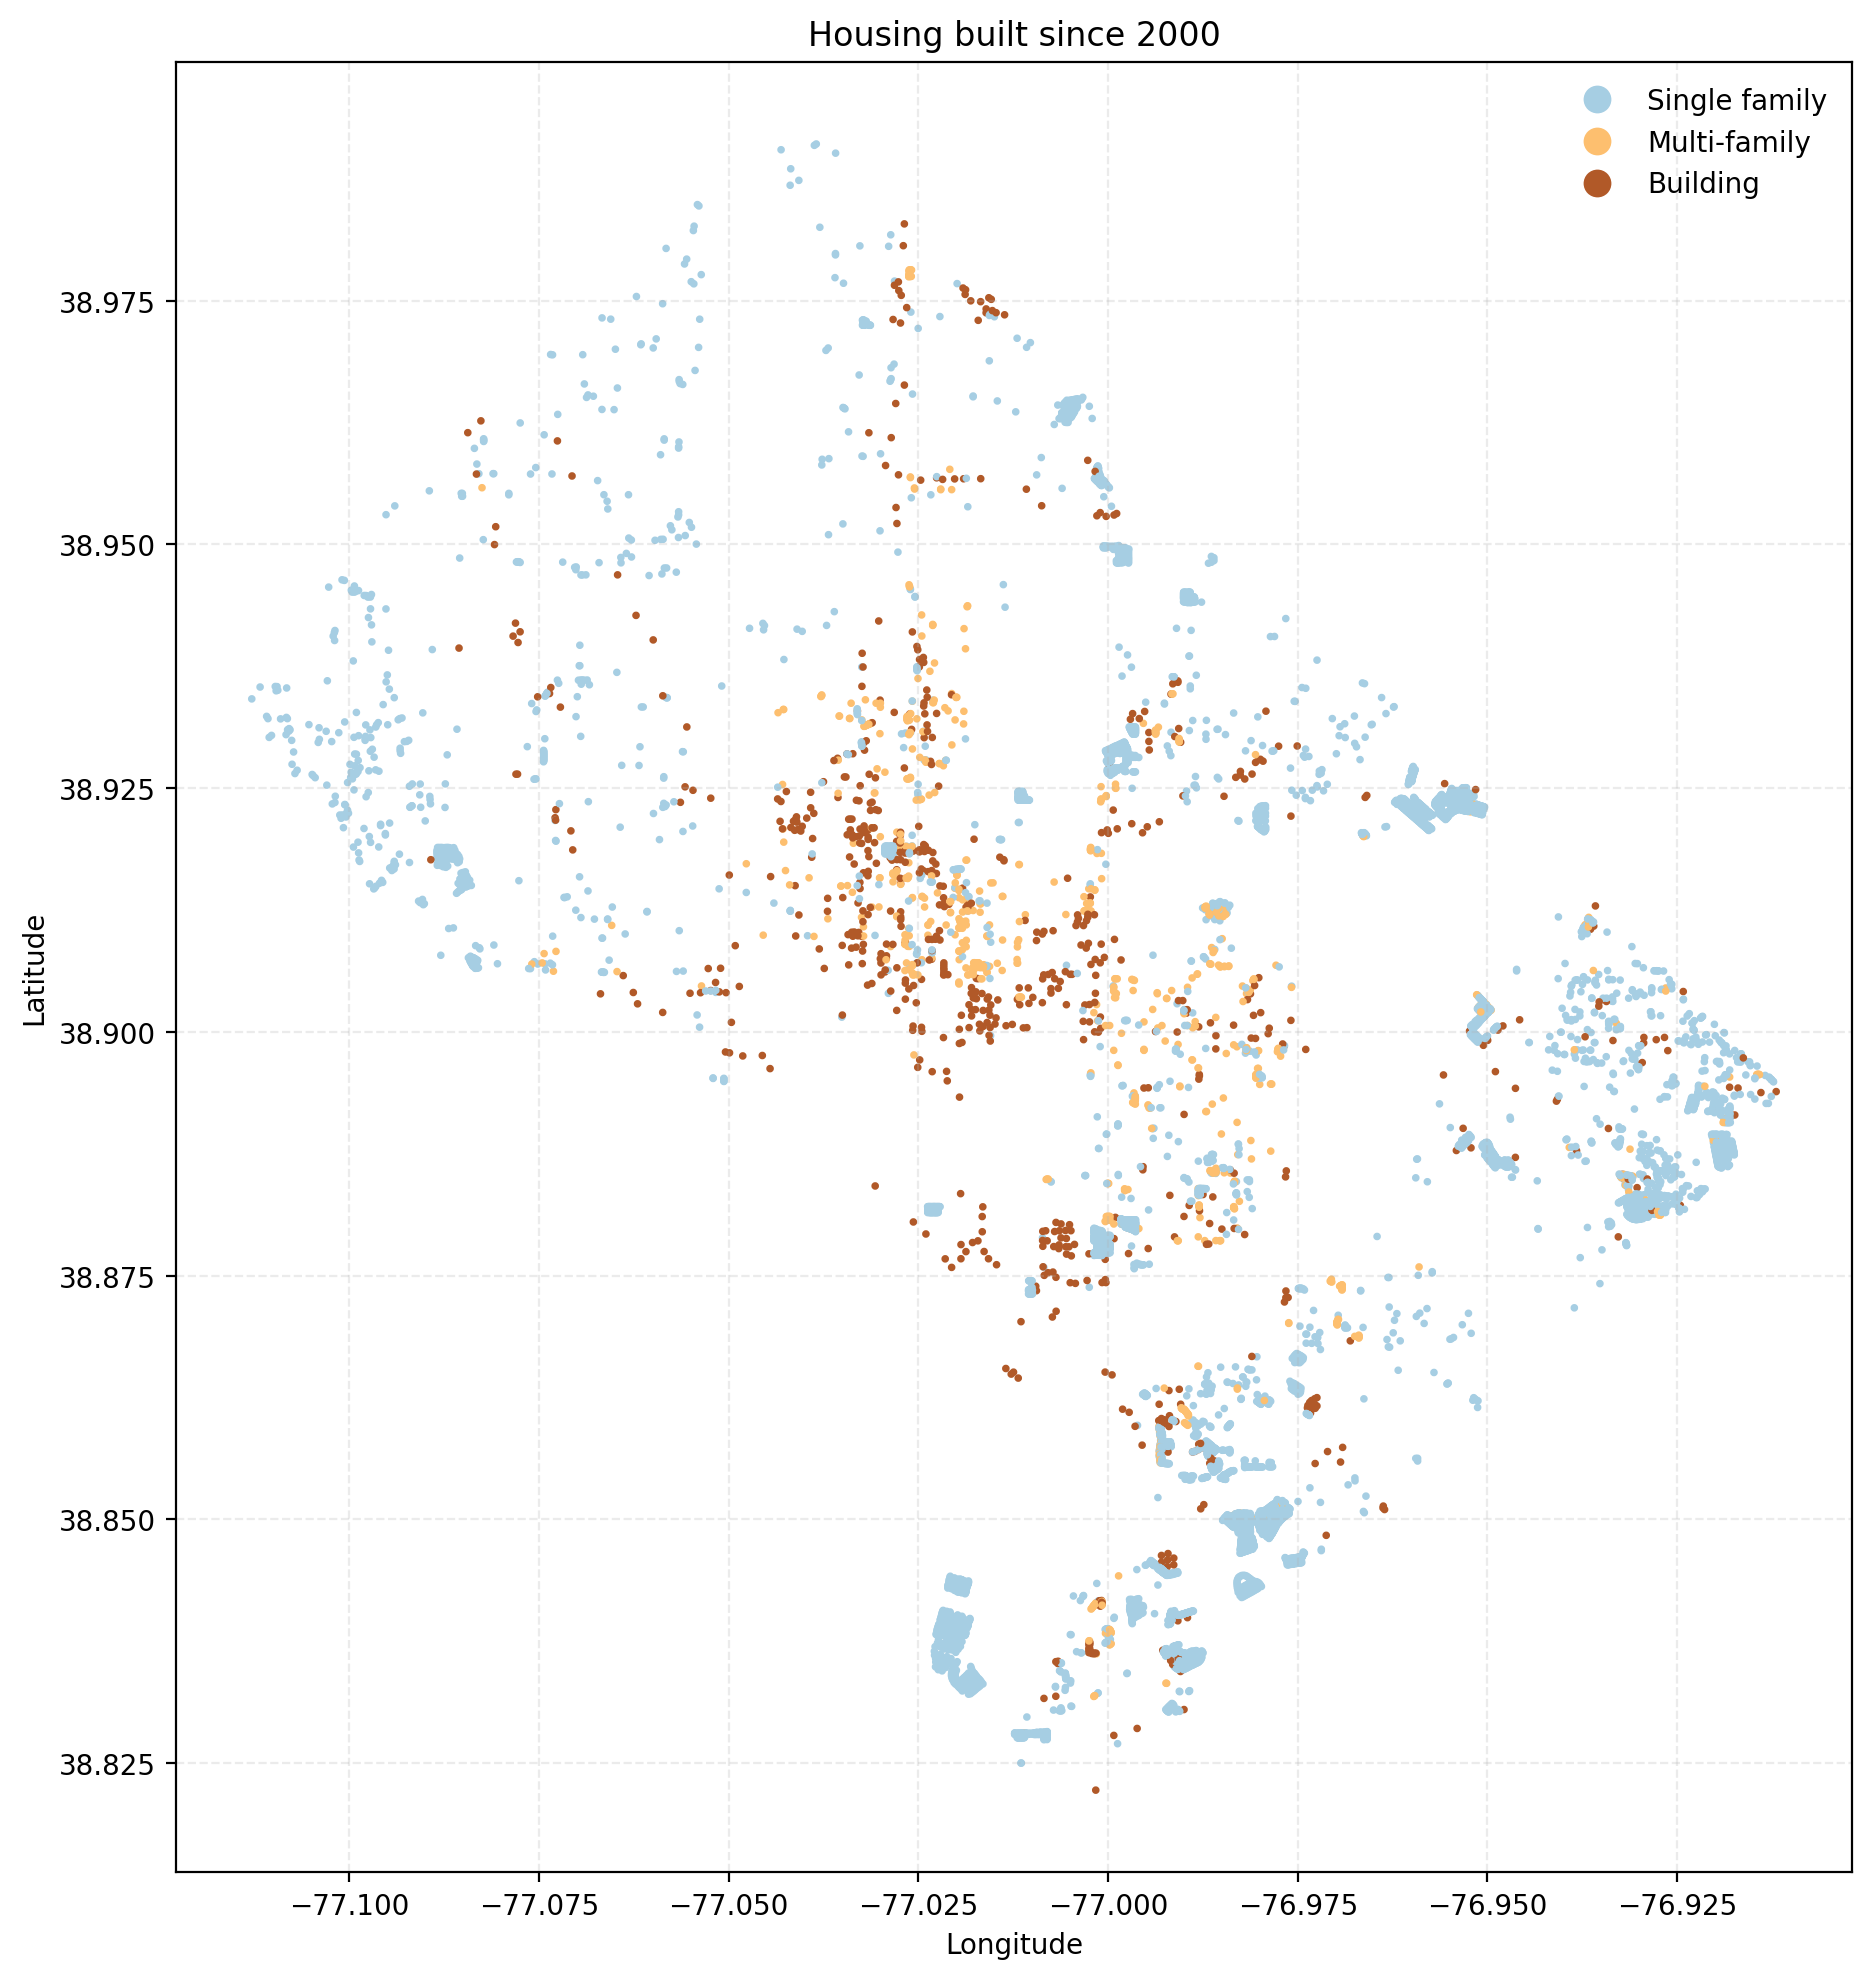

In [269]:
# Map spatial distribution of housing types
fig, ax = plt.subplots(figsize=(10,10), tight_layout=True)
tmp = address[address.year > 2000]
tmp.plot(column="housing_type", 
        cmap="Paired",
        #alpha=0.75, 
        categorical=True,
        markersize=3, 
        legend=True,
        legend_kwds={'frameon': False}, 
        ax=ax)
ax.set(xlabel="Longitude",
       ylabel="Latitude",
       title="Housing built since 2000")
ax.grid(zorder=0, ls="--", alpha=0.25)




### Time series view: Sum housing units by year of construction

In [270]:
# Sum buildings by year of construction
housing_type_starts = (address.groupby(["year","housing_type"], as_index=False)["total_housing_units"].size()
       .sort_values(by="year")).rename(columns={"size":"starts"})
housing_type_starts

,year,housing_type,starts
0,1869.0,Single family,193
1,1869.0,Multi-family,73
2,1869.0,Building,4
3,1870.0,Single family,14
4,1870.0,Multi-family,5
...,...,...,...
460,2023.0,Building,28
461,2024.0,Single family,25
462,2024.0,Multi-family,3
463,2024.0,Building,6


In [271]:
# Sum total_housing_units by year of construction
housing_starts = (address.groupby("year", as_index=False)["total_housing_units"].sum()
       .sort_values(by="year"))

# Compute cumulative housing starts
housing_starts["total_housing_cumsum"] = housing_starts["total_housing_units"].cumsum()

### Read ancillary data: DC population time series

In [272]:
# Load population data
pop = pd.read_csv(CSV_PATHS['population'])
pop["year"] = pd.to_datetime(pop["observation_date"]).dt.year
pop["population"] = pop["DCPOP"]*1000

# Drop redundant columns
pop = pop[["year","population"]]
pop.head()

,year,population
0,1900,278000.0
1,1901,285000.0
2,1902,290000.0
3,1903,295000.0
4,1904,302000.0


In [273]:
# Merge address and population data
df = housing_starts.merge(pop, on="year", how='left')

# Compute annual household size
df["household_size"] = df["population"] / df["total_housing_cumsum"]

# Compute effective people housed
df["people_housed"] = df["total_housing_units"]*df["household_size"]
df.head()

,year,total_housing_units,total_housing_cumsum,population,household_size,people_housed
0,1869.0,650.0,650.0,NaN,NaN,NaN
1,1870.0,31.0,681.0,NaN,NaN,NaN
2,1871.0,54.0,735.0,NaN,NaN,NaN
3,1872.0,358.0,1093.0,NaN,NaN,NaN
4,1873.0,192.0,1285.0,NaN,NaN,NaN


### Housing Appraisal

In [274]:
# Read mass appraisal data
appraisal = pd.read_csv(CSV_PATHS['appraisal'])

# Columns of interest: "AVLAND", "AVTOTAL", "BLDGCL", "USECODE"
print(appraisal.columns)
appraisal.head()

Index(['OBJECTID', 'SSL', 'BATHRM', 'HF_BATHRM', 'HEAT', 'HEAT_D', 'AC',
       'NUM_UNITS', 'ROOMS', 'BEDRM', 'AYB', 'YR_RMDL', 'EYB', 'STORIES',
       'SALEDATE', 'PRICE', 'QUALIFIED', 'SALE_NUM', 'GBA', 'BLDG_NUM',
       'STYLE', 'STYLE_D', 'STRUCT', 'STRUCT_D', 'GRADE', 'GRADE_D', 'CNDTN',
       'CNDTN_D', 'EXTWALL', 'EXTWALL_D', 'ROOF', 'ROOF_D', 'INTWALL',
       'INTWALL_D', 'KITCHENS', 'FIREPLACES', 'USECODE', 'LANDAREA',
       'GIS_LAST_MOD_DTTM'],
      dtype='str')


,OBJECTID,SSL,BATHRM,HF_BATHRM,HEAT,HEAT_D,AC,NUM_UNITS,ROOMS,BEDRM,...,EXTWALL_D,ROOF,ROOF_D,INTWALL,INTWALL_D,KITCHENS,FIREPLACES,USECODE,LANDAREA,GIS_LAST_MOD_DTTM
0,184582008,0132 0216,5.0,1.0,1.0,Forced Air,Y,3.0,15.0,6.0,...,Stone/Stucco,2.0,Built Up,6.0,Hardwood,3.0,6.0,25,1381,2026/04/08 05:16:11+00
1,184582009,0132 0217,5.0,0.0,1.0,Forced Air,Y,5.0,13.0,5.0,...,Common Brick,2.0,Built Up,6.0,Hardwood,5.0,0.0,25,1381,2026/04/08 05:16:11+00
2,184582010,0132 0222,2.0,0.0,1.0,Forced Air,Y,1.0,8.0,5.0,...,Common Brick,6.0,Metal- Sms,6.0,Hardwood,1.0,1.0,11,1620,2026/04/08 05:16:11+00
3,184582011,0132 0223,4.0,1.0,8.0,Ht Pump,Y,1.0,12.0,4.0,...,Common Brick,2.0,Built Up,6.0,Hardwood,1.0,0.0,11,1575,2026/04/08 05:16:11+00
4,184582012,0132 0227,2.0,0.0,7.0,Warm Cool,Y,2.0,6.0,2.0,...,Common Brick,2.0,Built Up,6.0,Hardwood,2.0,2.0,24,2250,2026/04/08 05:16:11+00


In [275]:
# Extract sale year
appraisal["SALE_YEAR"] = pd.to_datetime(appraisal["SALEDATE"], errors='coerce').dt.year

# Compute median and mean price by year
annual_price = appraisal.groupby('SALE_YEAR')['PRICE'].agg(['mean', 'median']).reset_index()

# Minimal data pre-1980 (drop)
annual_price = annual_price[annual_price.SALE_YEAR > 1980].reset_index(drop=True)

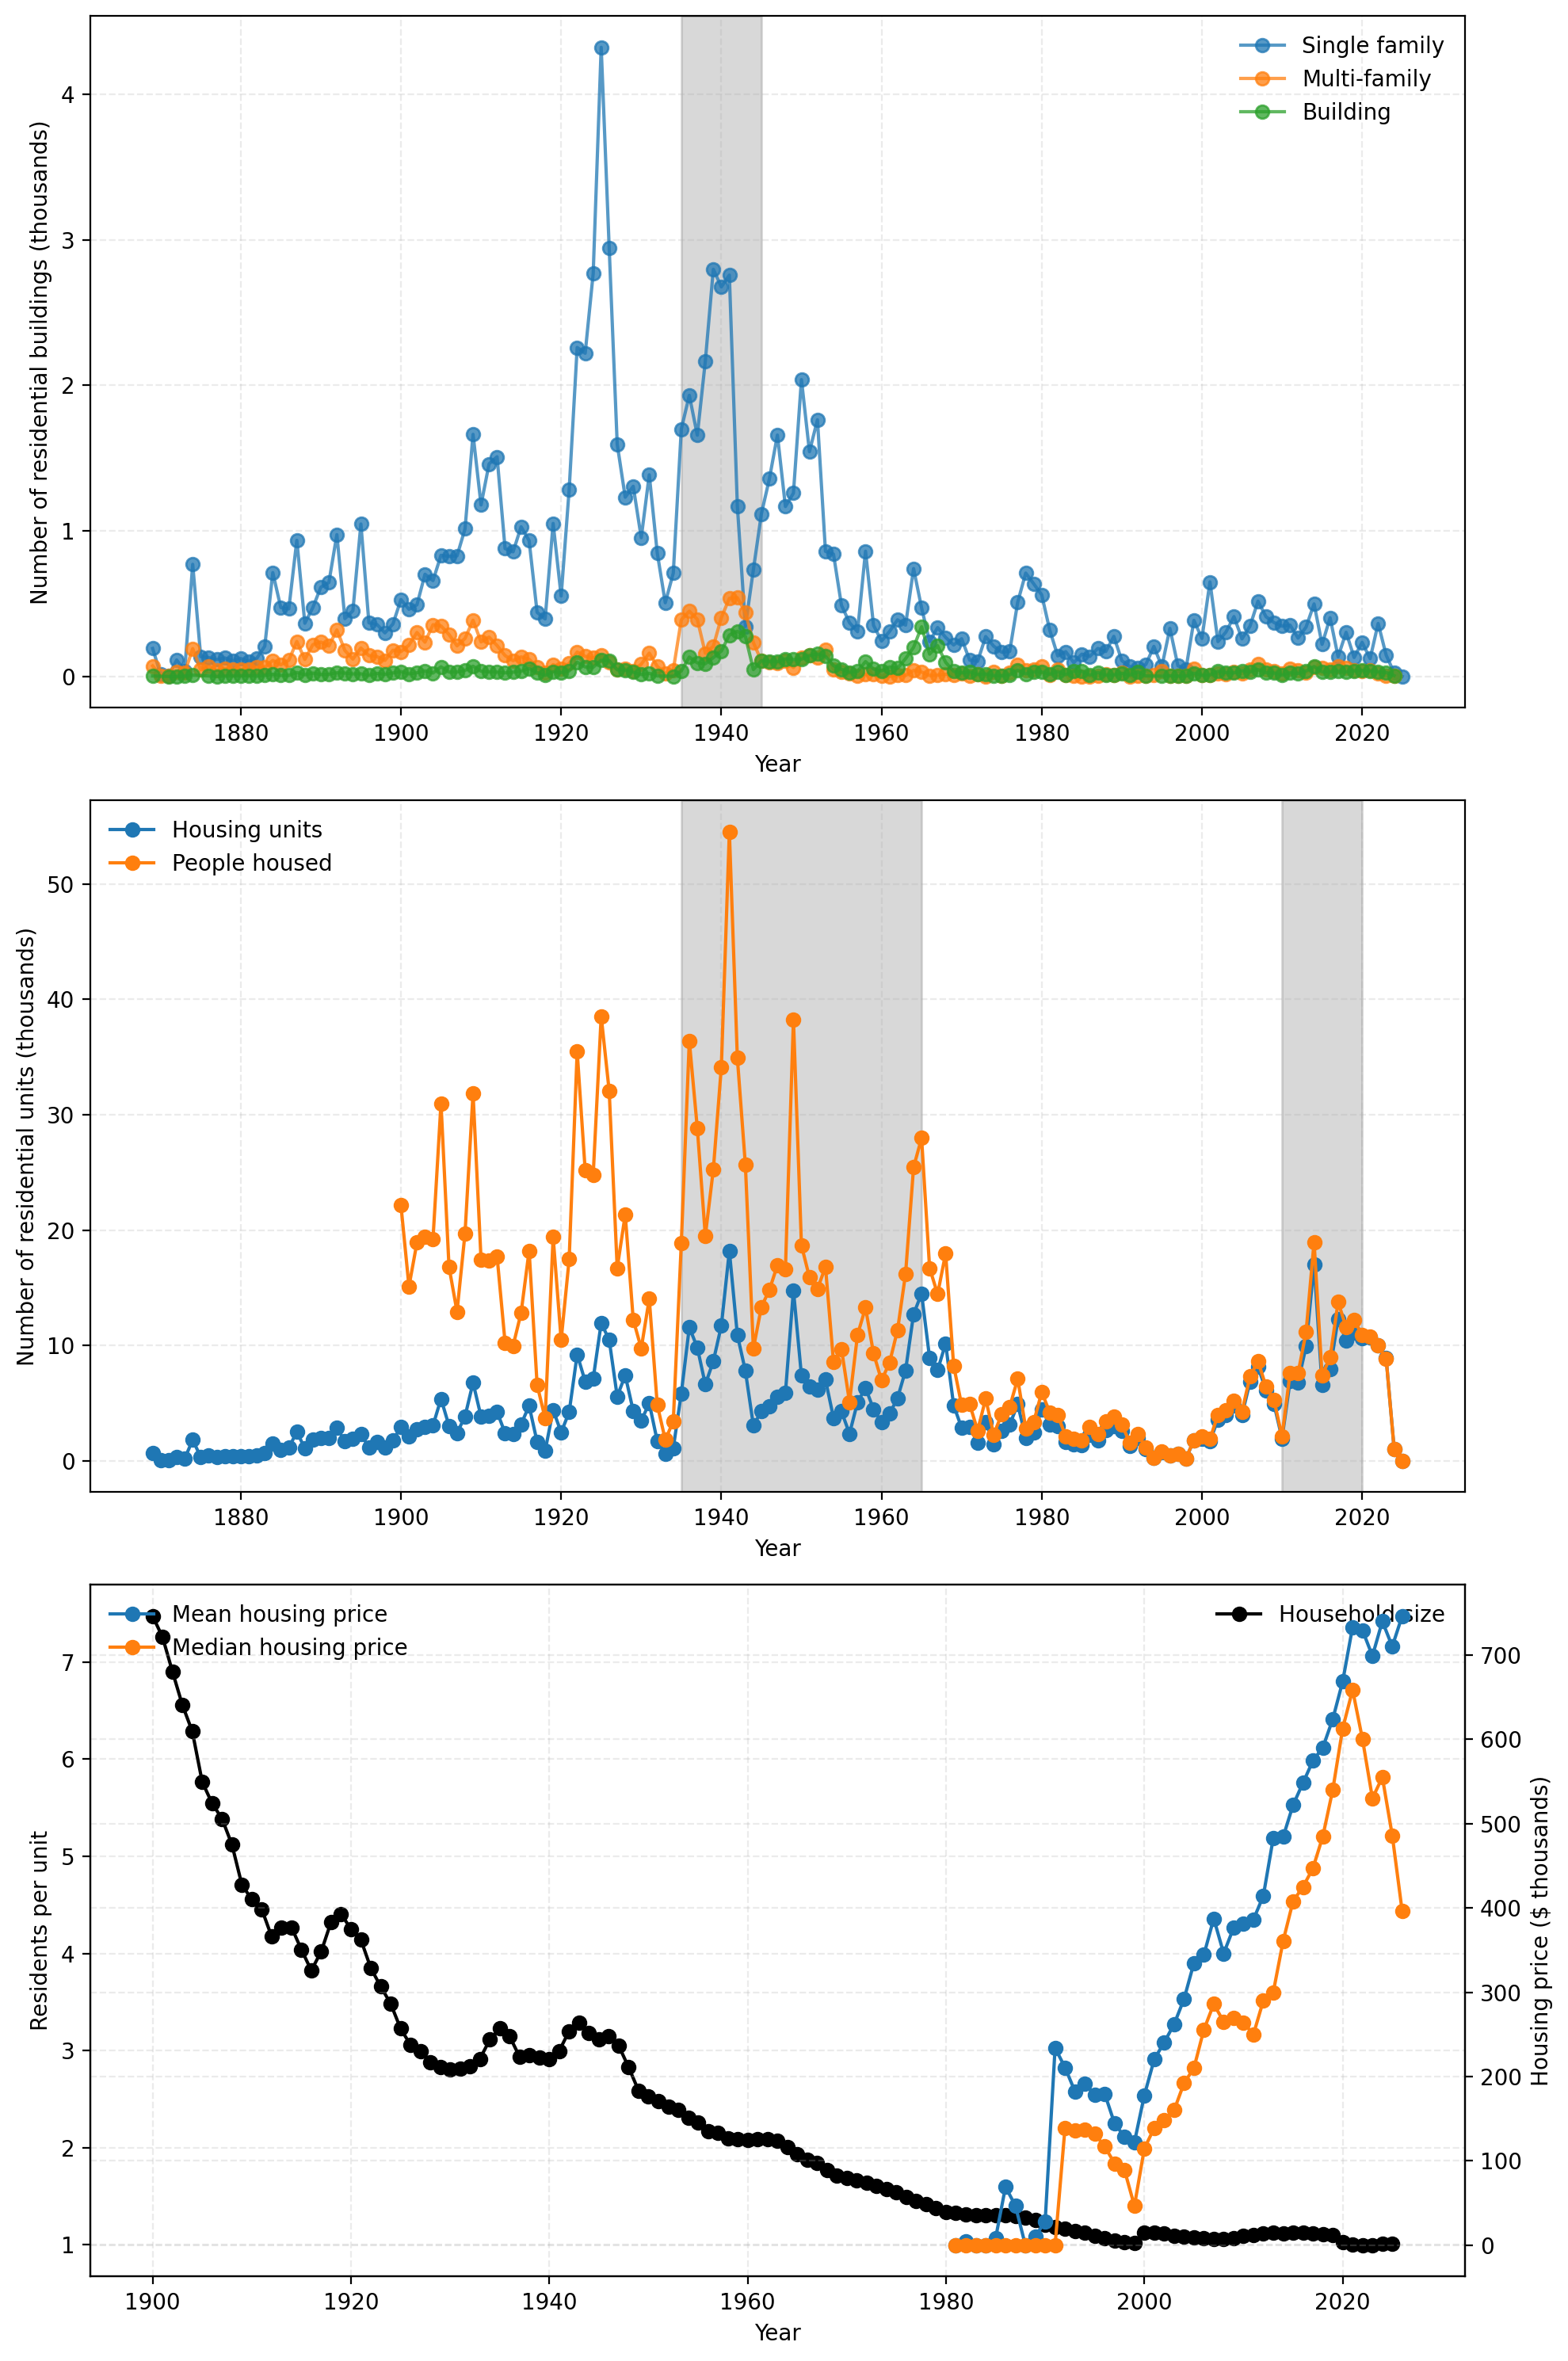

In [276]:
fig,(ax0,ax1,ax2) = plt.subplots(nrows=3, figsize=(10,15), tight_layout=True)

# Plot number of new building per year
for housing_type in housing_type_starts["housing_type"].unique():
    tmp = housing_type_starts[housing_type_starts.housing_type == housing_type].reset_index(drop=True)
    ax0.plot(tmp["year"], tmp["starts"], marker='o', ls='-', alpha=0.75, label=housing_type)
ax0.axvspan(1935, 1945, color='gray', alpha=0.3)
ax0.set(xlabel="Year", ylabel="Number of residential buildings (thousands)")
ax0.yaxis.set_major_formatter(mtick.FuncFormatter(thousands_formatter))
ax0.grid(zorder=0, ls="--", alpha=0.25)
ax0.legend(frameon=False)

# Plot number of new units per year
ax1.plot(df["year"], df["total_housing_units"], marker='o', ls='-', label="Housing units")
ax1.plot(df["year"], df["people_housed"], marker='o', ls='-', label="People housed")
ax1.axvspan(1935, 1965, color='gray', alpha=0.3)
ax1.axvspan(2010, 2020, color='gray', alpha=0.3)
ax1.set(xlabel="Year", ylabel="Number of residential units (thousands)")
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(thousands_formatter))

ax1.grid(zorder=0, ls="--", alpha=0.25)
ax1.legend(frameon=False)

# Plot household size over time
ax2.plot(df["year"], df["household_size"], marker='o', ls='-', color="k", label="Household size")
ax2.set(xlabel="Year", ylabel="Residents per unit")
ax2.grid(zorder=0, ls="--", alpha=0.25)
ax2.legend(frameon=False)

# Compute mean price by year
ax3 = ax2.twinx()

ax3.plot(annual_price["SALE_YEAR"], annual_price["mean"], marker='o', ls='-', label="Mean housing price")
ax3.plot(annual_price["SALE_YEAR"], annual_price["median"], marker='o', ls='-', label="Median housing price")
ax3.set(ylabel="Housing price ($ thousands)")
ax3.yaxis.set_major_formatter(mtick.FuncFormatter(thousands_formatter))

ax3.legend(frameon=False)
ax3.grid(zorder=0, ls="--", alpha=0.25)

